In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from scipy.special import expit
import pandas as pd
import sys
from sklearn.metrics import accuracy_score
import struct
# Load the data
data = pd.read_csv('Leases_WithDates_FixedNA.csv')

In [24]:
Month_Fixed_m = {
    '1/1/2018': 1,
    '2/1/2018': 2,
    '3/1/2018': 3,
    '4/1/2018': 4,
    '5/1/2018': 5,
    '6/1/2018': 6,
    '7/1/2018': 7,
    '8/1/2018': 8,
    '9/1/2018': 9,
    '10/1/2018': 10,
    '11/1/2018': 11,
    '12/1/2018': 12,
    '1/1/2019': 13,
    '2/1/2019': 14,
    '3/1/2019': 15,
    '4/1/2019': 16,
    '5/1/2019': 17,
    '6/1/2019': 18,
    '7/1/2019': 19,
    '8/1/2019': 20,
    '9/1/2019': 21,
    '10/1/2019': 22,
    '11/1/2019': 23,
    '12/1/2019': 24,
    '1/1/2020': 25,
    '2/1/2020': 26,
    '3/1/2020': 27,
    '4/1/2020': 28,
    '5/1/2020': 29,
    '6/1/2020': 30,
    '7/1/2020': 31,
    '8/1/2020': 32,
    '9/1/2020': 33,
    '10/1/2020': 34,
    '11/1/2020': 35,
    '12/1/2020': 36,
    '1/1/2021': 37,
    '2/1/2021': 38,
    '3/1/2021': 39,
    '4/1/2021': 40,
    '5/1/2021': 41,
    '6/1/2021': 42,
    '7/1/2021': 43,
    '8/1/2021': 44,
    '9/1/2021': 45,
    '10/1/2021': 46,
    '11/1/2021': 47,
    '12/1/2021': 48,
    '1/1/2022': 49,
    '2/1/2022': 50,
    '3/1/2022': 51,
    '4/1/2022': 52,
    '5/1/2022': 53,
    '6/1/2022': 54,
    '7/1/2022': 55,
    '8/1/2022': 56,
    '9/1/2022': 57,
    '10/1/2022': 58,
    '11/1/2022': 59,
    '12/1/2022': 60,
    '1/1/2023': 61,
    '2/1/2023': 62,
    '3/1/2023': 63,
    '4/1/2023': 64,
    '5/1/2023': 65,
    '6/1/2023': 66,
    '7/1/2023': 67,
    '8/1/2023': 68,
    '9/1/2023': 69,
    '10/1/2023': 70,
    '11/1/2023': 71,
    '12/1/2023': 72,
    '1/1/2024': 73,
    '2/1/2024': 74,
    '3/1/2024': 75,
    '4/1/2024': 76,
    '5/1/2024': 77,
    '6/1/2024': 78,
    '7/1/2024': 79,
    '8/1/2024': 80,
    '9/1/2024': 81,
    '10/1/2024': 82,
    '11/1/2024': 83,
    '12/1/2024': 84
}

Quarter_Fixed_m = {
    '3/1/2018': 1,
    '6/1/2018': 2,
    '9/1/2018': 3,
    '12/1/2018': 4,
    '3/1/2019': 5,
    '6/1/2019': 6,
    '9/1/2019': 7,
    '12/1/2019': 8,
    '3/1/2020': 9,
    '6/1/2020': 10,
    '9/1/2020': 11,
    '12/1/2020': 12,
    '3/1/2021': 13,
    '6/1/2021': 14,
    '9/1/2021': 15,
    '12/1/2021': 16,
    '3/1/2022': 17,
    '6/1/2022': 18,
    '9/1/2022': 19,
    '12/1/2022': 20,
    '3/1/2023': 21,
    '6/1/2023': 22,
    '9/1/2023': 23,
    '12/1/2023': 24,
    '3/1/2024': 25,
    '6/1/2024': 26,
    '9/1/2024': 27,
    '12/1/2024': 28,
}

CBD_suburban_m = {
    'CBD': 0,
    'Suburban': 1
}

space_type_m = {
    'Relet': 1,
    'New': 2,
    'Sublet': 3
}

transaction_type_m = {
    'Expansion': 1,
    'New': 2,
    'Relocation': 3,
    'Renewal': 4,
    'Restructure': 5,
    'Extension': 6,
    'TBD': 7,
    'Renewal and Expansion': 8,
    'Sale - Leaseback': 9
}

internal_industry_m = {
    'Financial Services and Insurance': 1,
    'Construction, Engineering and Architecture': 2,
    'Technology, Advertising, Media, and Information': 3,
    'Manufacturing (except Pharmaceutical, Retail, and Computer Tech)': 4,
    'Associations and Non-profit Organizations (except Education and Non-profit Hospitals)': 5,
    'Transportation': 6,
    'Coworking and Executive Suite Companies': 7,
    'Business, Professional, and Consulting Services (except Financial and Legal) - Including Accounting': 8,
    'Education': 9,
    'Legal Services': 10,
    'Real Estate (except coworking providers)': 11,
    'Healthcare': 12,
    'Personal Services and Recreation': 13,
    'Government': 14,
    'Retail': 15,
    'Energy & Utilities': 16,
    'TBD': 17,
    'Pharmaceuticals': 18,
    'Agriculture, Forestry, Fishing, Metal & Mineral Mining': 19,
    'Unclassifiable': 20   
}

internal_class_m = {
    'A': 1,
    'O': 0
}

market_m = {
    'Atlanta': 1,
    'Austin': 2,
    'Baltimore': 3,
    'Boston': 4,
    'Charlotte': 5,
    'Chicago': 6,   
    'Chicago Suburbs': 7,
    'Dallas/Ft Worth': 8,
    'Denver': 9,
    'Detroit': 10,
    'Houston': 11,
    'Los Angeles': 12,
    'Manhattan': 13,
    'Nashville': 14,
    'Northern New Jersey': 15,
    'Northern Virginia': 16,
    'Orange County': 17,
    'Philadelphia': 18,
    'Phoenix': 19,
    'Raleigh/Durham': 20,
    'Salt Lake City': 21,
    'San Diego': 22,
    'San Francisco': 23,
    'Seattle': 24,
    'South Bay/San Jose': 25,
    'South Florida': 26,
    'Southern Maryland': 27,
    'Tampa': 28,
    'Washington D.C.': 29
}

region_m = {
    'South': 1,
    'Northeast': 2,
    'Midwest/Central': 3,
    'West': 4
}

quarter_m = {
    'Q1': 1,
    'Q2': 2,
    'Q3': 3,
    'Q4': 4
}

state_m = {   
    'AL': 1,
    'AK': 2,
    'AZ': 3,
    'AR': 4,
    'CA': 5,
    'CO': 6,
    'CT': 7,
    'DE': 8,
    'FL': 9,
    'GA': 10,
    'HI': 11,
    'ID': 12,
    'IL': 13,
    'IN': 14,
    'IA': 15,
    'KS': 16,
    'KY': 17,
    'LA': 18,
    'ME': 19,
    'MD': 20,
    'MA': 21,
    'MI': 22,
    'MN': 23,
    'MS': 24,
    'MO': 25,
    'MT': 26,
    'NE': 27,
    'NV': 28,
    'NH': 29,
    'NJ': 30,
    'NM': 31,
    'NY': 32,
    'NC': 33,
    'ND': 34,
    'OH': 35,
    'OK': 36,
    'OR': 37,
    'PA': 38,
    'RI': 39,
    'SC': 40,
    'SD': 41,
    'TN': 42,
    'TX': 43,
    'UT': 44,
    'VT': 45,
    'VA': 46,
    'WA': 47,
    'WV': 48,
    'WI': 49,
    'WY': 50,
    'DC': 51,
    'PR': 52
}

In [25]:
data['Month_Fixed'] = data['Month_Fixed'].map(Month_Fixed_m)
data['Quarter_Fixed'] = data['Quarter_Fixed'].map(Quarter_Fixed_m)
data['CBD_suburban'] = data['CBD_suburban'].map(CBD_suburban_m)
data['space_type'] = data['space_type'].map(space_type_m)
data['transaction_type'] = data['transaction_type'].map(transaction_type_m)
data['internal_industry'] = data['internal_industry'].map(internal_industry_m)
data['internal_class'] = data['internal_class'].map(internal_class_m)
data['market'] = data['market'].map(market_m)
data['region'] = data['region'].map(region_m)
data['quarter'] = data['quarter'].map(quarter_m)
data['state'] = data['state'].map(state_m) 

del data['internal_submarket']
del data['internal_market_cluster']
del data['company_name']
del data['building_name']
del data['address']
del data['city']
data['building_id'] = data['building_id'].apply(hash)


In [26]:
from sklearn.preprocessing import StandardScaler

# Your custom list of columns to standardize
cols_to_standardize = ['leasedSF','RBA','available_space','availability_proportion','internal_class_rent', 'overall_rent',
                       'direct_available_space','direct_availability_proportion','direct_internal_class_rent',
                       'direct_overall_rent','sublet_available_space','sublet_availability_proportion',
                       'sublet_internal_class_rent','sublet_overall_rent','leasing']

scaler = StandardScaler()
data[cols_to_standardize] = scaler.fit_transform(data[cols_to_standardize])

In [27]:
data

,year,quarter,monthsigned,market,building_id,region,state,zip,internal_class,leasedSF,...,direct_availability_proportion,direct_internal_class_rent,direct_overall_rent,sublet_available_space,sublet_availability_proportion,sublet_internal_class_rent,sublet_overall_rent,leasing,Quarter_Fixed,Month_Fixed
0,2018,1,1.0,1,964244211931876162,1,10,30328.0,1,0.725037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.098929,1,1
1,2018,1,1.0,1,-8589178902107435572,1,10,30339.0,1,-0.267720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.098929,1,1
2,2018,1,1.0,1,-773539364630174122,1,10,30339.0,1,-0.215516,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.098929,1,1
3,2018,1,1.0,1,3481053110024772965,1,10,30339.0,0,-0.227627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.495458,1,1
4,2018,1,1.0,1,-5343738726769851032,1,10,30338.0,1,-0.207623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.098929,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145536,2024,4,12.0,28,115331286024987728,1,9,33607.0,1,0.512796,...,-0.355118,-0.286703,-0.654526,-0.529144,1.020291,-0.460610,-0.732526,-0.451184,28,84
145537,2024,4,12.0,28,-1394034588094604572,1,9,33607.0,1,0.369547,...,-0.355118,-0.286703,-0.654526,-0.529144,1.020291,-0.460610,-0.732526,-0.451184,28,84
145538,2024,4,12.0,28,422431877844940269,1,9,33602.0,0,0.045923,...,-0.489087,-0.736353,-0.654526,-0.745189,-0.014758,-0.718706,-0.732526,-0.808864,28,84
145539,2024,4,12.0,28,-8508403068985292703,1,9,33602.0,1,-0.223910,...,-0.355118,-0.286703,-0.654526,-0.529144,1.020291,-0.460610,-0.732526,-0.451184,28,84


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145541 entries, 0 to 145540
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   year                            145541 non-null  int64  
 1   quarter                         145541 non-null  int64  
 2   monthsigned                     144858 non-null  float64
 3   market                          145541 non-null  int64  
 4   building_id                     145541 non-null  int64  
 5   region                          145541 non-null  int64  
 6   state                           145541 non-null  int64  
 7   zip                             145540 non-null  float64
 8   internal_class                  145541 non-null  int64  
 9   leasedSF                        145541 non-null  float64
 10  internal_industry               20587 non-null   float64
 11  transaction_type                145167 non-null  float64
 12  costarID        

In [29]:
data2 = pd.read_csv('MajorMarketOccupancyData-revised.csv')


unique = data2['market'].unique()
print(unique, " ", len(unique))

data2['quarter'] = data2['quarter'].map(quarter_m)
data2['market'] = data2['market'].map(market_m)
print(data2.describe())


['Washington D.C.' 'Manhattan' 'Chicago' 'Houston' 'Philadelphia'
 'San Francisco' 'Los Angeles' 'Dallas/Ft Worth' 'South Bay/San Jose'
 'Austin']   10
              year     quarter      market  ending_occupancy_proportion  \
count   190.000000  190.000000  190.000000                   190.000000   
mean   2021.894737    2.421053   14.700000                     0.351158   
std       1.376090    1.094275    8.365304                     0.152696   
min    2020.000000    1.000000    2.000000                     0.080000   
25%    2021.000000    1.000000    8.000000                     0.220000   
50%    2022.000000    2.000000   12.500000                     0.355000   
75%    2023.000000    3.000000   23.000000                     0.470000   
max    2024.000000    4.000000   29.000000                     0.660000   

       starting_occupancy_proportion  avg_occupancy_proportion  
count                     190.000000                190.000000  
mean                        0.377895      

In [30]:
data2.head()

,year,quarter,market,ending_occupancy_proportion,starting_occupancy_proportion,avg_occupancy_proportion
0,2020,1,29,0.19,0.98,0.785714
1,2020,1,13,0.08,0.98,0.732857
2,2020,1,6,0.14,0.99,0.788571
3,2020,1,11,0.33,0.99,0.835714
4,2020,1,18,0.20,0.99,0.817143


In [31]:
merged = pd.merge(data, data2, on=['year', 'quarter', 'market'], how='inner')
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37780 entries, 0 to 37779
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   year                            37780 non-null  int64  
 1   quarter                         37780 non-null  int64  
 2   monthsigned                     37666 non-null  float64
 3   market                          37780 non-null  int64  
 4   building_id                     37780 non-null  int64  
 5   region                          37780 non-null  int64  
 6   state                           37780 non-null  int64  
 7   zip                             37780 non-null  float64
 8   internal_class                  37780 non-null  int64  
 9   leasedSF                        37780 non-null  float64
 10  internal_industry               5703 non-null   float64
 11  transaction_type                37680 non-null  float64
 12  costarID                        

In [34]:
summary = merged.describe()
summary = summary.transpose()
# Drop only the columns you don't need for calculations
columns_to_drop = ['year','quarter', 'monthsigned', 'market', 'building_id', 'region', 'state', 'zip', 
                   'internal_class', 'leasedSF', 'internal_industry', 'transaction_type', 
                   'costarID', 'space_type', 'CBD_suburban']
summary.drop(columns_to_drop, axis=0, inplace=True)

# Ensure 'summarynont' retains necessary columns
summarynont = summary.copy()

# Transpose back for further processing
summary = summary.transpose()

# Initialize the data description DataFrame
data_des = pd.DataFrame()
data_des['Attributes'] = merged.columns
data_des['Description'] = 'N/A'
data_des['Mean'] = 'N/A'
data_des['Std Deviation'] = 'N/A'
data_des['Range'] = 'N/A'
data_des['Median'] = 'N/A'

data_des['Description']= ['Year of Sale (Dropped in Model for Month,Quarter Fixed)','Quarter of Sale (Dropped in Model)',
                          'Month of Sale (Dropped in Model)','Market (One-Hot Encoded)','Building ID (Dropped in Model)',
                          'Region (Dropped in Model)','State (Dropped in Model)','Zip Code (Dropped in Model)','Quality of Building,'
                          ' Turned into boolean', 'Leased Square Footage (Standardized)','Internal Industry (One-Hot Encoded)',
                          'Transaction Type (One-Hot Encoded)','Costar ID (Dropped in Model)','Space Type (One-Hot Encoded)',
                          'CBD/Suburban (Boolean)', 'Total Leaseable Square Footage (Standardized)', 'Available Square Footage (Standardized)',
                          'Availability Proportion (Standardized)','Internal Class Rent (Standardized)','Overall Rent (Standardized)',
                          'Direct Available Square Footage (Standardized)','Direct Availability Proportion (Standardized)',
                          'Direct Internal Class Rent (Standardized)','Direct Overall Rent (Standardized)',
                          'Sublet Available Square Footage (Standardized)','Sublet Availability Proportion (Standardized)',
                          'Sublet Internal Class Rent (Standardized)','Sublet Overall Rent (Standardized)',
                          'Leasing Rate (Standardized)','Sequential Quarters','Sequential Months','End occupancy', 'Start occupancy', 'Average occupancy']
# Update the description of the data
for col in merged.columns:
    if col not in columns_to_drop:  # Skip dropped columns
        if col in summarynont.index:  # Check if the column exists in summarynont
            data_des.loc[data_des['Attributes'] == col, 'Mean'] = round(merged[col].mean(), 5)
            data_des.loc[data_des['Attributes'] == col, 'Std Deviation'] = round(merged[col].std(), 5)
            data_des.loc[data_des['Attributes'] == col, 'Range'] = f"{round(summarynont.loc[col, 'min'], 3)}-{round(summarynont.loc[col, 'max'], 3)}"
            data_des.loc[data_des['Attributes'] == col, 'Median'] = round(merged[col].median(), 5)

data_des

,Attributes,Description,Mean,Std Deviation,Range,Median
0,year,"Year of Sale (Dropped in Model for Month,Quart...",N/A,N/A,N/A,N/A
1,quarter,Quarter of Sale (Dropped in Model),N/A,N/A,N/A,N/A
2,monthsigned,Month of Sale (Dropped in Model),N/A,N/A,N/A,N/A
3,market,Market (One-Hot Encoded),N/A,N/A,N/A,N/A
4,building_id,Building ID (Dropped in Model),N/A,N/A,N/A,N/A
5,region,Region (Dropped in Model),N/A,N/A,N/A,N/A
6,state,State (Dropped in Model),N/A,N/A,N/A,N/A
7,zip,Zip Code (Dropped in Model),N/A,N/A,N/A,N/A
8,internal_class,"Quality of Building, Turned into boolean",N/A,N/A,N/A,N/A
9,leasedSF,Leased Square Footage (Standardized),N/A,N/A,N/A,N/A


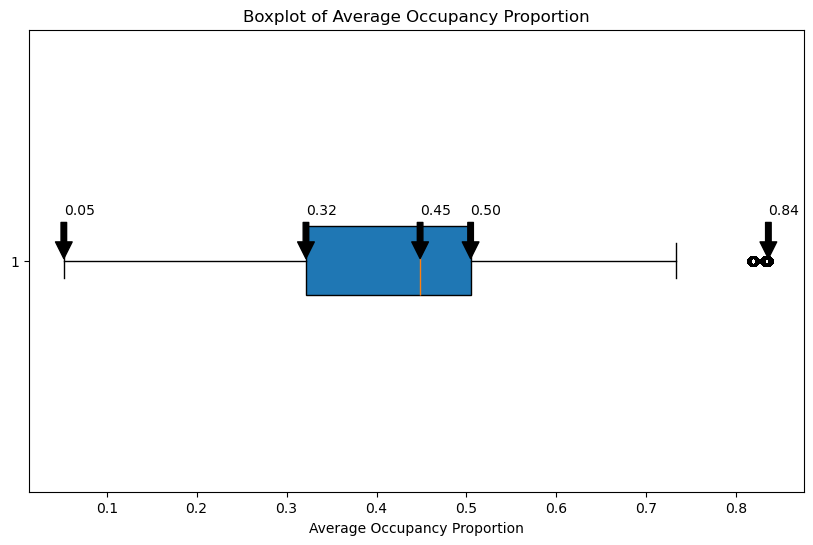

In [35]:
occupancy = merged['avg_occupancy_proportion'].dropna()

plt.figure(figsize=(10, 6))
box = plt.boxplot(occupancy, vert=False, patch_artist=True)

# Extracting the statistics
stats = {
    'min': occupancy.min(),
    'Q1': occupancy.quantile(0.25),
    'median': occupancy.median(),
    'Q3': occupancy.quantile(0.75),
    'max': occupancy.max()
}

# Adding annotations
for key, value in stats.items():
    plt.annotate(f'{value:.2f}', xy=(value, 1), xytext=(value, 1.1),
                 arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Boxplot of Average Occupancy Proportion')
plt.xlabel('Average Occupancy Proportion')
plt.show()

In [36]:
bins = [merged['avg_occupancy_proportion'].min(), merged['avg_occupancy_proportion'].quantile(0.25), merged['avg_occupancy_proportion'].median(), merged['avg_occupancy_proportion'].quantile(0.75), merged['avg_occupancy_proportion'].max()]
labels = [1, 2, 3, 4]

# Create a new column with the binned merged
merged['avg_occupancy_proportionClass'] = pd.cut(merged['avg_occupancy_proportion'], bins=bins, labels=labels, include_lowest=True)

# Print the relevant columns for visualization
print(merged[['avg_occupancy_proportion', 'avg_occupancy_proportionClass']])

       avg_occupancy_proportion avg_occupancy_proportionClass
0                      0.820000                             4
1                      0.820000                             4
2                      0.820000                             4
3                      0.820000                             4
4                      0.820000                             4
...                         ...                           ...
37775                  0.402308                             2
37776                  0.402308                             2
37777                  0.402308                             2
37778                  0.392308                             2
37779                  0.392308                             2

[37780 rows x 2 columns]


In [37]:
merged.head()

,year,quarter,monthsigned,market,building_id,region,state,zip,internal_class,leasedSF,...,sublet_availability_proportion,sublet_internal_class_rent,sublet_overall_rent,leasing,Quarter_Fixed,Month_Fixed,ending_occupancy_proportion,starting_occupancy_proportion,avg_occupancy_proportion,avg_occupancy_proportionClass
0,2020,1,1.0,2,7007109465475168011,1,43,78704.0,0,-0.194676,...,-0.896799,-0.344389,0.160765,-0.730261,9,25,0.26,0.98,0.82,4
1,2020,1,1.0,2,7007109465475168011,1,43,78704.0,0,-0.170203,...,-0.896799,-0.344389,0.160765,-0.730261,9,25,0.26,0.98,0.82,4
2,2020,1,1.0,2,-2508203528801593240,1,43,78701.0,1,0.044837,...,-0.167765,0.739872,0.160765,-0.230704,9,25,0.26,0.98,0.82,4
3,2020,1,1.0,2,7955492036809387747,1,43,78735.0,1,1.153488,...,-0.167765,0.739872,0.160765,-0.230704,9,25,0.26,0.98,0.82,4
4,2020,1,1.0,2,-2125367919161668019,1,43,78757.0,0,-0.270894,...,-0.896799,-0.344389,0.160765,-0.730261,9,25,0.26,0.98,0.82,4


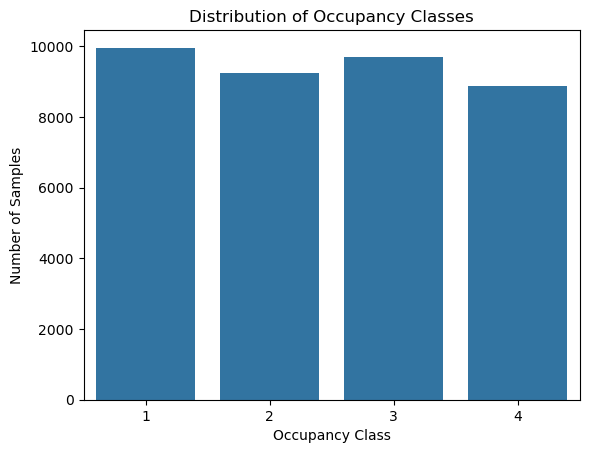

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='avg_occupancy_proportionClass', data=merged, order=sorted(merged['avg_occupancy_proportionClass'].unique()))
plt.xlabel('Occupancy Class')
plt.ylabel('Number of Samples')
plt.title('Distribution of Occupancy Classes')
plt.show()

In [72]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import numpy as np
from tensorflow.keras.preprocessing import sequence


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

merged = merged.dropna(subset=['avg_occupancy_proportionClass'])
merged['avg_occupancy_proportionClass'] = merged['avg_occupancy_proportionClass'].astype(int)

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(merged['avg_occupancy_proportionClass'], num_classes=5)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
print(type(X_train), X_train.shape)
print(type(X_train[0]), X_train[0].shape)
print('Vocabulary size:', np.max(X_train))
print(y_train.shape, np.min(y_train), np.max(y_train))

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input, Concatenate, Subtract

NUM_CLASSES = 4
NUM_FEATURES = X_train.shape[2]
TIME_STEPS = X_train.shape[1]

sequence_input = Input(shape=(TIME_STEPS, NUM_FEATURES))  # (24, num_features)

x = Conv1D(64, kernel_size=5, activation='relu', kernel_initializer='he_uniform')(sequence_input)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)

x = Conv1D(64, kernel_size=5, activation='relu', kernel_initializer='he_uniform')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)

x = Conv1D(64, kernel_size=3, activation='relu', kernel_initializer='he_uniform')(x)
x = Dropout(0.2)(x)

x_mean = GlobalAveragePooling1D()(x)
x_tmp = Subtract()([x, tf.expand_dims(x_mean, 1)])  # Subtract mean across time
x_std = GlobalAveragePooling1D()(x_tmp ** 2)

x = Concatenate(name='concat_1')([x_mean, x_std])

x = Dense(64, activation='relu', kernel_initializer='he_uniform')(x)
x = Dropout(0.2)(x)

preds = Dense(NUM_CLASSES, activation='softmax', kernel_initializer='glorot_uniform')(x)

model = Model(inputs=sequence_input, outputs=preds)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay


lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    decay_rate=0.95,
    staircase=True) 
# clipnorm=1.0, 

opt = Adam(epsilon=0.0001, learning_rate=lr_schedule)
model.compile(loss='binary_crossentropy',
              optimizer=opt,
              metrics=['acc'])

In [ ]:
%%time 

history = []
tmp = model.fit(X_train, y_train, epochs=5, 
                batch_size=64, 
                validation_data=(X_test, y_test))
history.append( tmp )

In [ ]:
# run this as many times as we want! Adds 5 epochs each time
tmp = model.fit(X_train, y_train, epochs=5, 
                batch_size=64, 
                validation_data=(X_test, y_test))
history.append( tmp )

In [ ]:
from sklearn import metrics as mt
from matplotlib import pyplot as plt
%matplotlib inline

# combine all the history from training together
combined = dict()
for key in ['acc','val_acc','loss','val_loss']:
    combined[key] = np.hstack([x.history[key] for x in history])
    
# summarize history for accuracy
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(combined['acc'])
plt.plot(combined['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

# summarize history for loss
plt.subplot(122)
plt.plot(combined['loss'])
plt.plot(combined['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()